In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [3]:
df_snapshot = pd.read_csv('/Users/tyco/Desktop/MADS/sanovo_19052025/data/processed/data_snapshots.csv')

In [4]:
# # Filter snapshots where the min and max MerDate within the same snapshot have the same date
# df_snapshot = df_snapshot.groupby('snapshot').filter(
#     lambda x: x['MerDate'].min().date() == x['MerDate'].max().date()
# )

In [5]:
# Convert MerDateDay to datetime if not already done
df_snapshot['MerDate'] = pd.to_datetime(df_snapshot['MerDate'] )

# Filter out weekend dates (Saturday and Sunday)
df_snapshot = df_snapshot[~df_snapshot['MerDate'].dt.weekday.isin([5, 6])]

In [6]:
df_snapshot['time_in_seconds'] = pd.to_timedelta(df_snapshot['time_delta']).dt.total_seconds()
df_snapshot.head()

,index,MerDate,MerId,MerType,MerNumber,MerSubNumber,MerData1,MerData2,MerData3,MerData4,...,MerMinId,MerText,MerDeviceType,MerDeviceNumber,MerPriority,Error/warnings,lane_stopping_machine,snapshot,time_delta,time_in_seconds
0,0,2025-01-30 10:21:42,11897186,21,460,12,1.0,22.0,41.0,NaN,...,4620,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,242.0
1,1,2025-01-30 10:21:56,11897187,23,460,12,0.0,0.0,0.0,NaN,...,4620,NaN,0,0,0,23_460_0.0_0.0,NaN,1,0 days 00:04:02,242.0
2,2,2025-01-30 10:21:56,11897188,21,460,12,1.0,22.0,41.0,NaN,...,4620,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,242.0
3,3,2025-01-30 10:21:57,11897189,23,460,12,0.0,0.0,0.0,NaN,...,4620,NaN,0,0,0,23_460_0.0_0.0,NaN,1,0 days 00:04:02,242.0
4,4,2025-01-30 10:21:57,11897190,21,460,12,1.0,22.0,41.0,NaN,...,4620,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,242.0


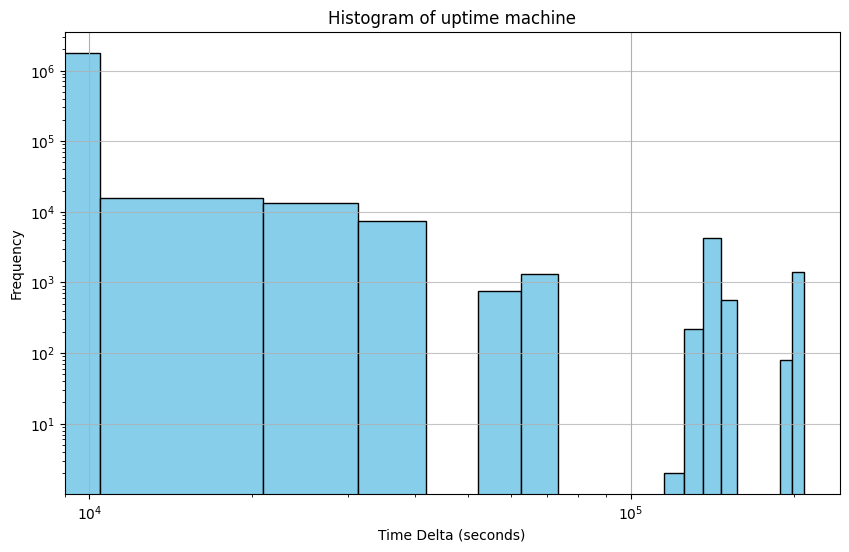

In [7]:
plt.figure(figsize=(10, 6))
df_snapshot['time_in_seconds'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of uptime machine')
plt.xlabel('Time Delta (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xscale('log')
plt.yscale('log')
plt.show()

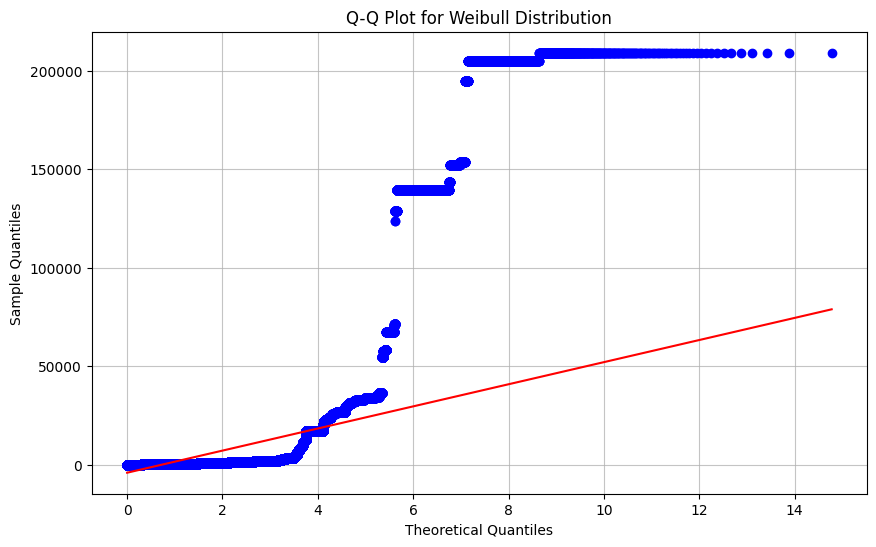

In [8]:
from scipy.stats import probplot

import matplotlib.pyplot as plt

# Generate a Q-Q plot for the Weibull distribution
plt.figure(figsize=(10, 6))
probplot(df_snapshot['time_in_seconds'], dist="weibull_min", sparams=(1,), plot=plt)
plt.title('Q-Q Plot for Weibull Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

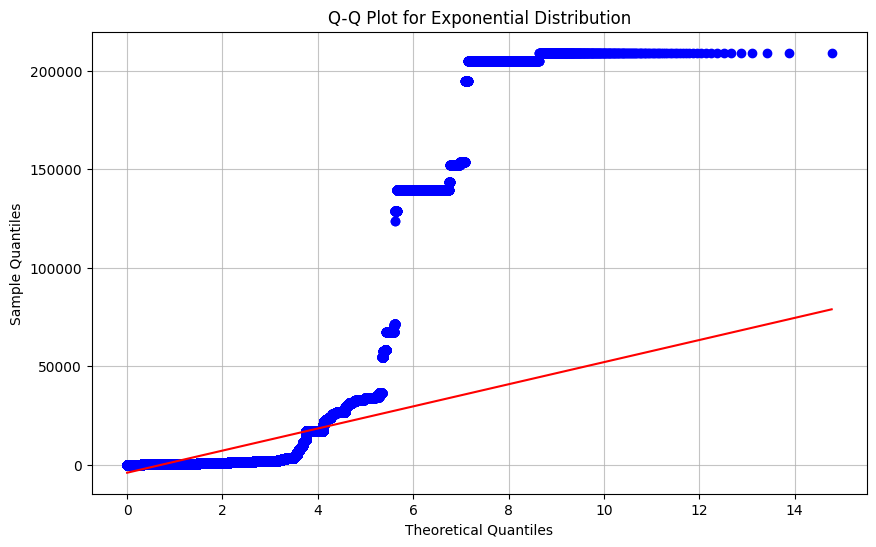

In [9]:
# Generate a Q-Q plot for the Exponential distribution
plt.figure(figsize=(10, 6))
probplot(df_snapshot['time_in_seconds'], dist="expon", plot=plt)
plt.title('Q-Q Plot for Exponential Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

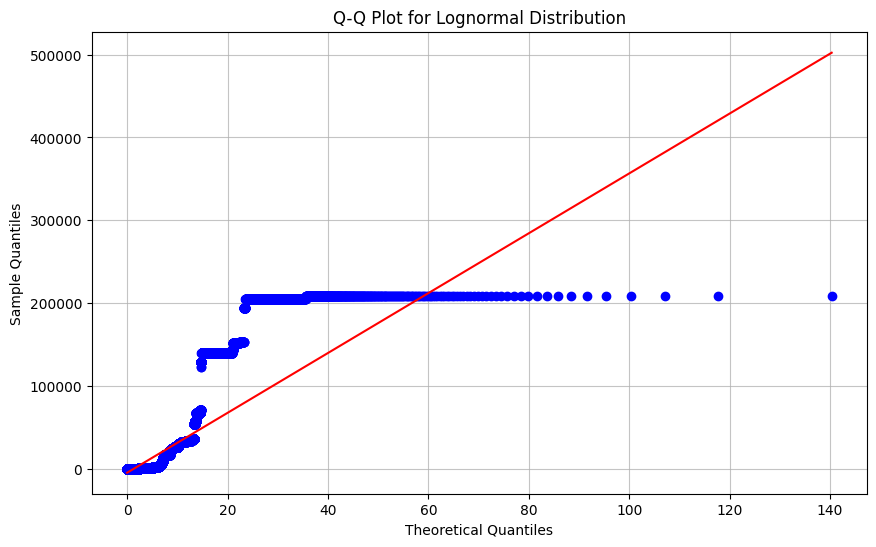

In [10]:
# Generate a Q-Q plot for the Lognormal distribution
plt.figure(figsize=(10, 6))
probplot(df_snapshot['time_in_seconds'], dist="lognorm", sparams=(1,), plot=plt)
plt.title('Q-Q Plot for Lognormal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

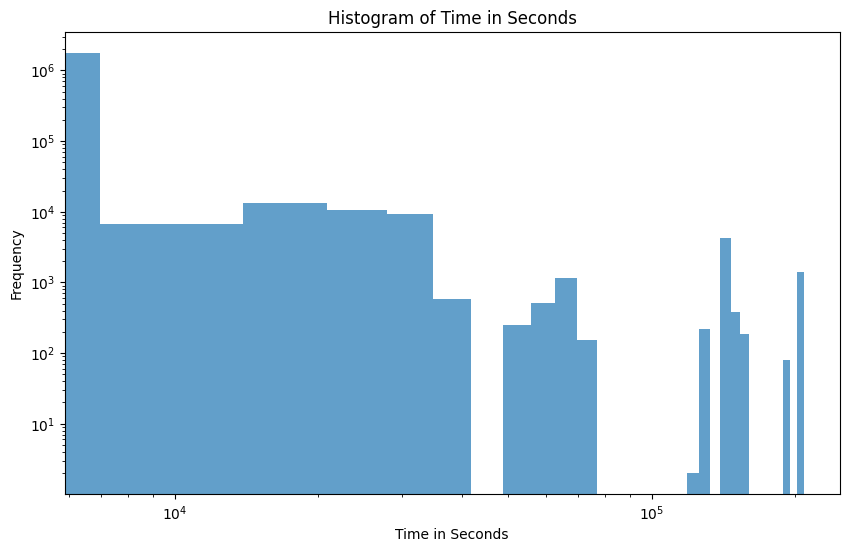

In [11]:
# Create a histogram for the 'time_in_seconds' column
plt.figure(figsize=(10, 6))
df_snapshot['time_in_seconds'].plot.hist(bins=30, alpha=0.7)
plt.title('Histogram of Time in Seconds')
plt.xlabel('Time in Seconds')
plt.ylabel('Frequency')
plt.xscale('log')
plt.yscale('log')
plt.show()

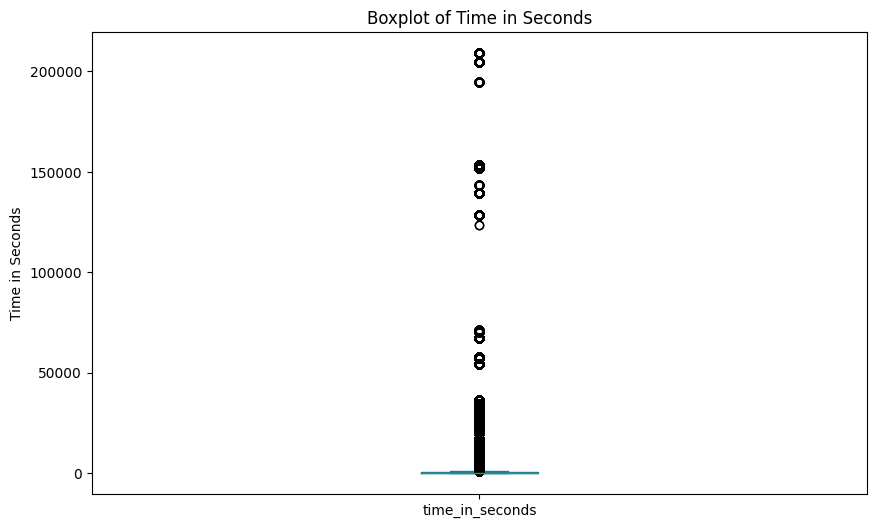

In [12]:
import matplotlib.pyplot as plt

# Create a boxplot for the 'time_in_seconds' column
plt.figure(figsize=(10, 6))
df_snapshot['time_in_seconds'].plot.box()
plt.title('Boxplot of Time in Seconds')
plt.ylabel('Time in Seconds')
plt.show()

In [13]:
df_snapshot[df_snapshot['snapshot'] == 806]['MerDate'].agg(['min', 'max'])

min   2025-01-31 20:47:02
max   2025-02-03 05:42:14
Name: MerDate, dtype: datetime64[ns]

In [14]:
long_uptime = df_snapshot[df_snapshot['time_in_seconds'] > 100000]

In [15]:
short_uptime = df_snapshot[df_snapshot['time_in_seconds'] < 30]

/var/folders/pt/00xl4yzd64s0vbx9w9tzh94m0000gn/T/ipykernel_89706/3205456412.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  long_agg = long_uptime.groupby('snapshot').apply(


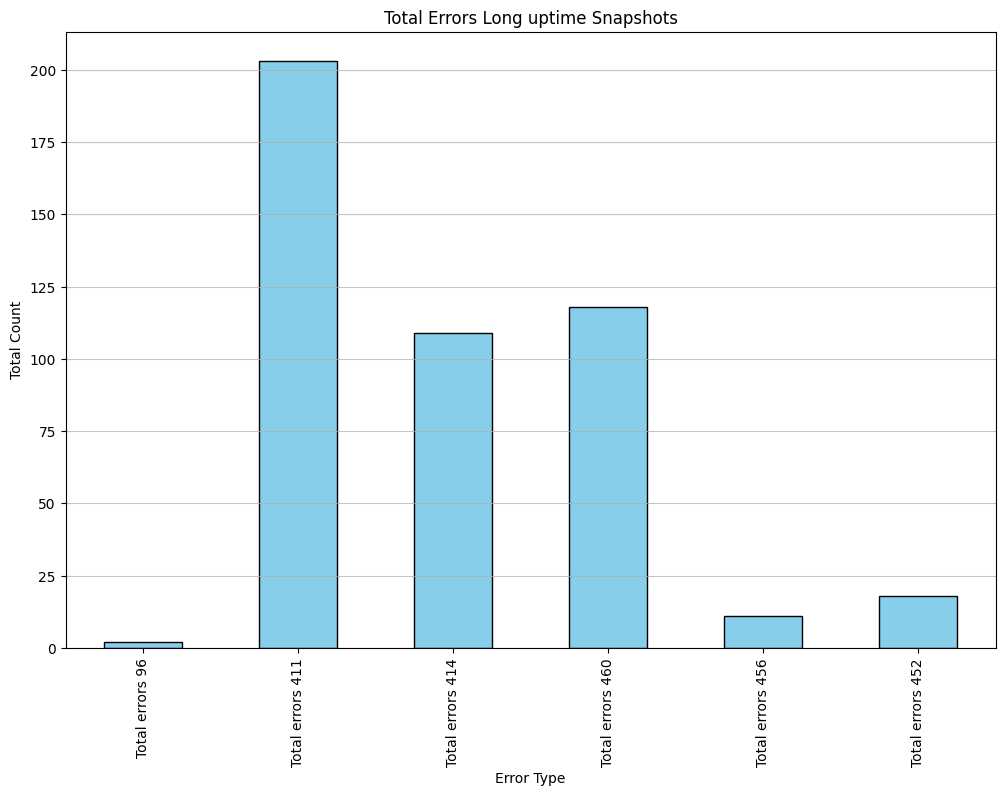

In [16]:
long_agg = long_uptime.groupby('snapshot').apply(
    lambda x: pd.Series({
        'Total errors 96': ((x['MerType'] == 21) & (x['MerNumber'] == 96)).sum(),
        'Total errors 411': ((x['MerType'] == 21) & (x['MerNumber'] == 411)).sum(),
        'Total errors 414': ((x['MerType'] == 21) & (x['MerNumber'] == 414)).sum(),
        'Total errors 460': ((x['MerType'] == 21) & (x['MerNumber'] == 460)).sum(),
        'Total errors 456': ((x['MerType'] == 21) & (x['MerNumber'] == 456)).sum(),
        'Total errors 452': ((x['MerType'] == 21) & (x['MerNumber'] == 452)).sum(),
        'Total stops': ((x['MerType'] == 8) & (x['MerNumber'] == 0)).sum()
    })
)

long_agg.head()

# Create histograms for each error column in long_agg
error_columns = ['Total errors 96', 'Total errors 411', 'Total errors 414', 'Total errors 460', 'Total errors 456', 'Total errors 452']
# Create a bar chart for each error column in long_agg
plt.figure(figsize=(12, 8))
long_agg[error_columns].sum().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Errors Long uptime Snapshots')
plt.xlabel('Error Type')
plt.ylabel('Total Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

/var/folders/pt/00xl4yzd64s0vbx9w9tzh94m0000gn/T/ipykernel_89706/2370666595.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  short_agg = short_uptime.groupby('snapshot').apply(


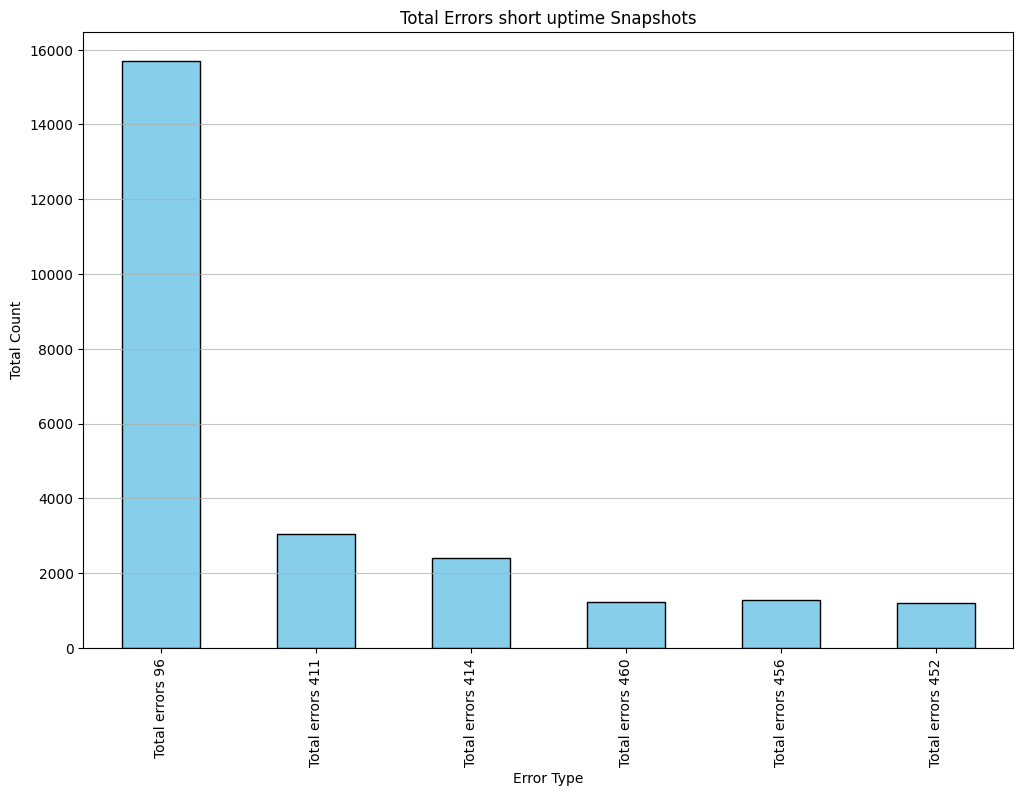

In [17]:
short_agg = short_uptime.groupby('snapshot').apply(
    lambda x: pd.Series({
        'Total errors 96': ((x['MerType'] == 21) & (x['MerNumber'] == 96)).sum(),
        'Total errors 411': ((x['MerType'] == 21) & (x['MerNumber'] == 411)).sum(),
        'Total errors 414': ((x['MerType'] == 21) & (x['MerNumber'] == 414)).sum(),
        'Total errors 460': ((x['MerType'] == 21) & (x['MerNumber'] == 460)).sum(),
        'Total errors 456': ((x['MerType'] == 21) & (x['MerNumber'] == 456)).sum(),
        'Total errors 452': ((x['MerType'] == 21) & (x['MerNumber'] == 452)).sum(),
        'Total stops': ((x['MerType'] == 8) & (x['MerNumber'] == 0)).sum()
    })
)

short_agg.head()

# Create histograms for each error column in long_agg
error_columns = ['Total errors 96', 'Total errors 411', 'Total errors 414', 'Total errors 460', 'Total errors 456', 'Total errors 452']
# Create a bar chart for each error column in long_agg
plt.figure(figsize=(12, 8))
short_agg[error_columns].sum().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Errors short uptime Snapshots')
plt.xlabel('Error Type')
plt.ylabel('Total Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [22]:
df_snapshot = df_snapshot[['MerType', 'MerNumber', 'MerSubNumber', 'time_in_seconds']]
df_snapshot.select_dtypes(include=['float64', 'int64']).columns

Index(['MerType', 'MerNumber', 'MerSubNumber', 'time_in_seconds'], dtype='object')

In [21]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

#init encoder
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# columns to encode
categorical_cols = ['MerType', 'MerNumber', 'MerSubNumber']

# encode
encoded_mertypes = onehot.fit_transform(df_snapshot[categorical_cols])

# get feature names out again
feature_names = onehot.get_feature_names_out(categorical_cols)

# create dataframe with columnnames
encoded_df = pd.DataFrame(encoded_mertypes, columns=feature_names)

# concat encoded columns with numerical column
encoded_df = pd.concat([df_snapshot.drop(columns=categorical_cols), encoded_df], axis=1)

encoded_df.head(5)


ValueError: Shape of passed values is (1810027, 1), indices imply (1810027, 143)

In [20]:
# init scaler
scaler = StandardScaler()

# scale the data to be clustered
scaled_data = scaler.fit_transform(encoded_df)
scaled_df = pd.DataFrame(scaled_data, columns=encoded_df.columns)

scaled_df.isnull().sum()

time_in_seconds     52573
MerType_8           52573
MerType_21          52573
MerType_22          52573
MerType_23          52573
                    ...  
MerSubNumber_48     52573
MerSubNumber_49     52573
MerSubNumber_50     52573
MerSubNumber_99     52573
MerSubNumber_255    52573
Length: 144, dtype: int64

In [146]:
wcss = []
# Try different values for k (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# Based on the elbow plot, choose an optimal K. Let's assume K=3 for this example.
# optimal_k = 3
# print(f"\nOptimal number of clusters (K) chosen based on Elbow Method: {optimal_k}")

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values